# ElideDB — database operations for analysis

Everything you do with a store from Python, on the Oxford database
(`lake/oxford` — build it with `oxford_upload.ipynb` if it doesn't exist):
**inventory · SQL · DataFrames · time windows · frame decode · alignment ·
semantic search (dynamic segments) · clip similarity · time travel ·
export**.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "python"))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from elidedb import Store

db = Store.open("../lake/oxford")
BASE = min(d["min_ts"] for d in db.describe()
           if d["rows"] and d["table"] != "centroids")
def T(sec):  # capture-relative seconds -> absolute ns
    return BASE + int(sec * 1e9)
def rel(ns):
    return (ns - BASE) / 1e9
print(db.name, "— opened")

oxford — opened


## Inventory — the database as a DataFrame

In [2]:
pd.DataFrame(db.describe())[["table","kind","rows","bytes","files","version"]]

,table,kind,rows,bytes,files,version
0,centroids,centroids,2,13134,1,1
1,embeddings,embeddings,120,819593,1,1
2,frames,frame_index,1443,21814,1,7
3,gps,timeseries,12636,1013296,1,1
4,ins,timeseries,126361,11448815,1,1
5,ldmrs,timeseries,238,8357,1,1
6,lms_front,timeseries,950,19490,1,1
7,lms_rear,timeseries,951,19043,1,1


## SQL (DuckDB over the store's own Parquet)

Table names in SQL are your table names. Any SELECT works — aggregates,
window functions, joins across tables.

In [3]:
db.sql('''
  SELECT count(*)                                              AS ins_rows,
         round(avg(sqrt(velocity_north^2 + velocity_east^2)),2) AS avg_speed_ms,
         round(max(sqrt(velocity_north^2 + velocity_east^2)),2) AS max_speed_ms,
         round((max(ts) - min(ts)) / 1e9)                       AS span_s
  FROM ins''')

,ins_rows,avg_speed_ms,max_speed_ms,span_s
0,126361,3.62,12.13,2527.0


In [4]:
# join two sensors on 1-second buckets — lidar clutter vs vehicle speed
db.sql('''
  WITH l AS (SELECT ts // 1000000000 AS sec, avg(mean_range) AS lidar_m
             FROM lms_front GROUP BY 1),
       v AS (SELECT ts // 1000000000 AS sec,
                    avg(sqrt(velocity_north^2 + velocity_east^2)) AS speed
             FROM ins GROUP BY 1)
  SELECT l.sec - (SELECT min(sec) FROM l) AS t_s,
         round(lidar_m, 1) AS lidar_range_m, round(speed, 2) AS speed_ms
  FROM l JOIN v USING (sec) ORDER BY 1 LIMIT 10''')

,t_s,lidar_range_m,speed_ms
0,0,214.1,7.56
1,1,213.5,7.27
2,2,207.1,6.97
3,3,196.9,6.69
4,4,200.8,6.44
5,5,213.0,6.20
6,6,214.8,6.02
7,7,209.0,6.03
8,8,215.0,6.09
9,9,209.4,6.20


## Tables → DataFrames, analysis-ready

`scan()` is the pruned columnar read: give it a time range and the columns
you want, get a pyarrow table — `.to_pandas()` and go.

In [5]:
ins = db.table("ins").scan(T(600), T(900),
                           columns=["ts","velocity_north","velocity_east","yaw"]
                           ).to_pandas()
ins["t_s"] = (ins.ts - BASE) / 1e9
ins["speed"] = np.hypot(ins.velocity_north, ins.velocity_east)
ins.describe().round(3)

,ts,velocity_north,velocity_east,yaw,t_s,speed
count,1.500000e+04,15000.000,15000.000,15000.000,15000.000,15000.000
mean,1.418382e+18,2.216,-1.023,3.837,750.009,4.204
std,8.660533e+10,2.849,3.438,2.220,86.605,2.867
min,1.418382e+18,-3.199,-6.924,0.000,600.019,0.000
25%,1.418382e+18,0.009,-3.329,1.099,675.014,1.583
50%,1.418382e+18,1.839,-1.368,4.620,750.009,4.799
75%,1.418382e+18,4.923,0.004,5.884,825.004,6.232
max,1.418382e+18,8.194,7.711,6.282,899.999,8.969


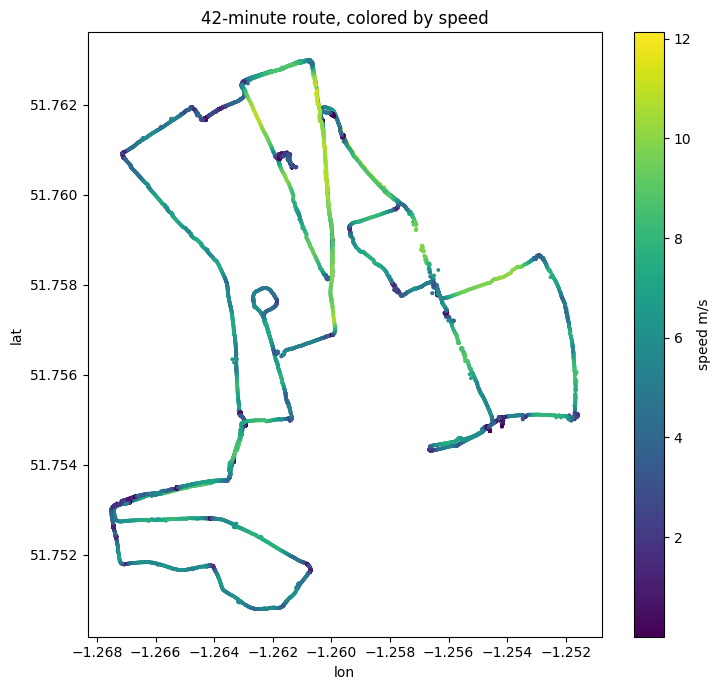

In [6]:
# the whole GPS track as a DataFrame + an analysis plot: route colored by speed
gps = db.table("gps").scan().to_pandas()
ins_all = db.table("ins").scan(columns=["ts","velocity_north","velocity_east"]).to_pandas()
ins_all["speed"] = np.hypot(ins_all.velocity_north, ins_all.velocity_east)
gps["speed"] = np.interp(gps.ts, ins_all.ts, ins_all.speed)
fig, ax = plt.subplots(figsize=(7.5, 7))
sc = ax.scatter(gps.longitude, gps.latitude, c=gps.speed, s=3, cmap="viridis")
fig.colorbar(sc, label="speed m/s"); ax.set_title("42-minute route, colored by speed")
ax.set_xlabel("lon"); ax.set_ylabel("lat"); plt.tight_layout()

## Time-window reads (the core multimodal query)

Everything overlapping [t0, t1], with honest byte accounting. Video comes
back as a lazy `FrameSet`; decoding preads exactly the frames you ask for.

<7/8 files, 7,682,737 B touched of 13,363,542 B (42.510% elided), 509 rows, 8.3 ms>


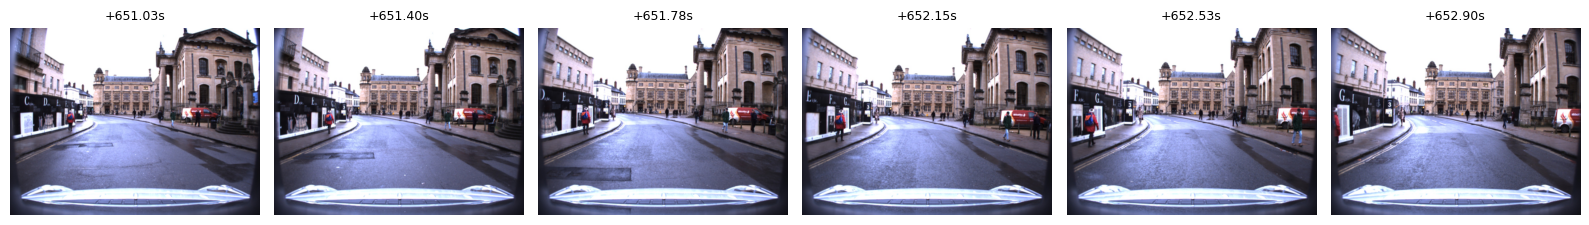

In [7]:
w, stats = db.window(T(651), T(653))
print(stats)
frames = w["frames"].decode(stream="stereo/centre", width=440, stride=6)
fig, axes = plt.subplots(1, len(frames), figsize=(16, 3))
for ax, (ts, img) in zip(axes, frames):
    ax.imshow(img); ax.set_title(f"+{rel(ts):.2f}s", fontsize=9); ax.axis("off")
plt.tight_layout()

## Query-time alignment

Resample every numeric stream onto one timeline — a tidy DataFrame for
modeling. Alignment is a query option, never a storage commitment.

,t_s,ins.latitude,ins.longitude,ins.altitude,ins.northing,ins.easting,ins.down,ins.velocity_north,ins.velocity_east,ins.velocity_down,ins.roll,ins.pitch,ins.yaw,lms_front.n_points,lms_front.mean_range,lms_front.min_range,lms_front.max_range,speed
0,645.00,51.754,-1.256,111.943,5735172.586,620380.246,-111.943,1.422,7.494,0.027,-0.022,-0.010,1.387,520.000,244.505,0.015,1019.915,7.628
1,645.05,51.754,-1.256,111.942,5735172.666,620380.619,-111.942,1.420,7.483,0.018,-0.021,-0.011,1.386,517.852,241.057,0.349,751.766,7.617
2,645.10,51.755,-1.256,111.941,5735172.746,620380.991,-111.941,1.421,7.468,0.024,-0.020,-0.012,1.386,516.000,165.229,0.326,592.602,7.602
3,645.15,51.755,-1.256,111.940,5735172.826,620381.362,-111.940,1.418,7.455,0.024,-0.019,-0.012,1.386,510.610,174.164,0.413,564.430,7.588


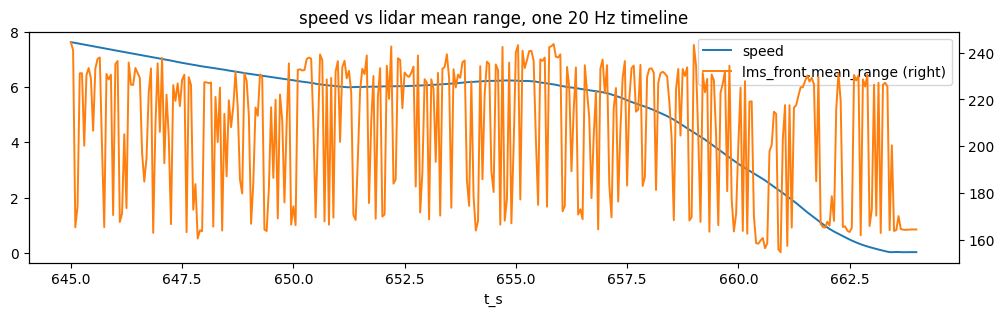

In [8]:
al, _ = db.aligned(T(645), T(664), rate_hz=20, tables=["ins", "lms_front"],
                   interp="linear")
df = pd.DataFrame({"t_s": (al["timeline_ns"] - BASE) / 1e9})
for tab, cols in al.items():
    if tab == "timeline_ns": continue
    for c, v in cols.items():
        df[f"{tab}.{c}"] = v
df["speed"] = np.hypot(df["ins.velocity_north"], df["ins.velocity_east"])
ax = df.plot(x="t_s", y=["speed", "lms_front.mean_range"], secondary_y=["lms_front.mean_range"],
             figsize=(12, 3), lw=1.4, title="speed vs lidar mean range, one 20 Hz timeline")
df.head(4).round(3)

## Semantic search — dynamic segments

Results are **merged segments**: consecutive matching windows fuse into one
hit of the event's true duration (no fixed chunks, no sub-clip duplicates).
`stats` reports the per-query threshold and how many windows merged.

In [9]:
hits, stats = db.search_text("pedestrians walking on the sidewalk past buildings", k=5)
print(stats)
hdf = pd.DataFrame(hits)
hdf["duration_s"] = (hdf.t1 - hdf.t0) / 1e9
hdf["start"] = hdf.t0.map(rel).round(1)
hdf[["score","stream","start","duration_s","windows"]]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

{'scanned': 120, 'total': 120, 'clusters_probed': 2, 'clusters_total': 2, 'threshold': 0.0837, 'qualifying_windows': 10, 'segments': 3}


,score,stream,start,duration_s,windows
0,0.097474,mono/left,659.7,4.119561,5
1,0.089865,mono/left,654.7,2.000000,2
2,0.087498,mono/right,657.7,3.000000,3


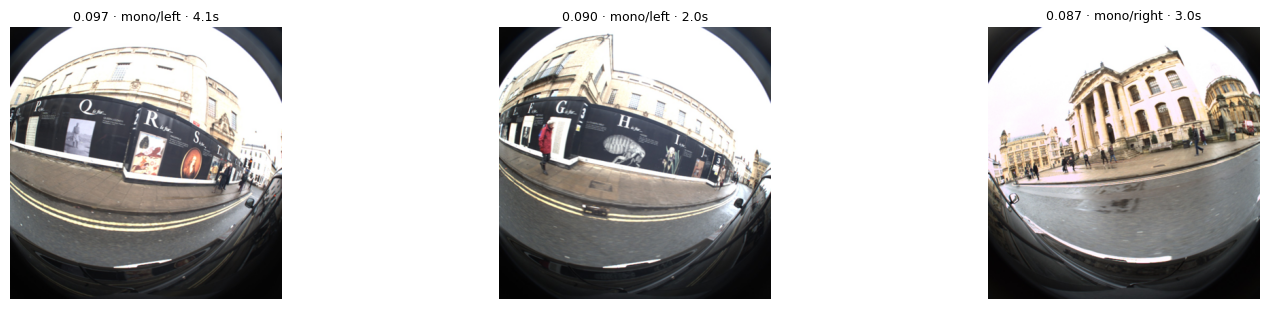

In [10]:
fig, axes = plt.subplots(1, len(hits), figsize=(16, 3.2))
for ax, h in zip(axes, hits):
    w, _ = db.window(h["t0"], h["t1"], tables=["frames"])
    dec = w["frames"].decode(stream=h["stream"], width=400, limit=1)
    if dec: ax.imshow(dec[0][1])
    ax.axis("off")
    ax.set_title(f"{h['score']:.3f} · {h['stream']} · {(h['t1']-h['t0'])/1e9:.1f}s",
                 fontsize=9)
plt.tight_layout()

## Clip similarity — “find moments like this one”

In [11]:
sim, sstats = db.search_clip("stereo/centre", T(652), T(654), k=4)
pd.DataFrame(sim).assign(start=lambda d: d.t0.map(rel).round(1),
                         duration_s=lambda d: (d.t1-d.t0)/1e9)[
    ["score","stream","start","duration_s","windows"]]

,score,stream,start,duration_s,windows
0,0.994270,stereo/right,646.7,15.000000,15
1,0.993378,stereo/left,646.7,15.000000,15
2,0.970654,stereo/right,644.8,0.923318,1


## Time travel

Every commit is a version; every old version stays readable forever.

In [12]:
print("frames table history:")
hist = pd.DataFrame(db.table("frames").history())
print(f"rows @v2: {db.table('frames').state(2).rows:,}   "
      f"rows now (v{db.table('frames').state().version}): {db.table('frames').state().rows:,}")
hist[["version","op","added_rows","ts_utc"]]

frames table history:
rows @v2: 542   rows now (v7): 1,443


,version,op,added_rows,ts_utc
0,1,append,271,2026-07-18T04:01:59Z
1,2,append,271,2026-07-18T04:01:59Z
2,3,append,271,2026-07-18T04:01:59Z
3,4,append,210,2026-07-18T04:01:59Z
4,5,append,210,2026-07-18T04:01:59Z
5,6,append,210,2026-07-18T04:01:59Z
6,7,adopt-media,1443,2026-07-19T16:37:30Z


## Export — take data anywhere

A windowed, projected slice out to Parquet/CSV for any other tool. (Other
engines can also read the store's Parquet files directly — nothing is
locked in.)

In [13]:
slice_df = db.table("ins").scan(T(600), T(660)).to_pandas()
slice_df.to_parquet("/tmp/oxford_ins_600_660.parquet")
slice_df.to_csv("/tmp/oxford_ins_600_660.csv", index=False)
print(f"exported {len(slice_df):,} rows ->",
      "/tmp/oxford_ins_600_660.parquet + .csv")

# training-data example: dump every frame of a search hit as numpy arrays
h = hits[0]
w, _ = db.window(h["t0"], h["t1"], tables=["frames"])
clip = w["frames"].decode(stream=h["stream"], width=640)
arr = np.stack([f for _, f in clip])
print("clip tensor for training:", arr.shape, arr.dtype)

exported 3,000 rows -> /tmp/oxford_ins_600_660.parquet + .csv


clip tensor for training: (46, 640, 640, 3) uint8


---
Also see: `oxford_upload.ipynb` (build/clear this database) ·
`elidedb desk` (visual browser) · `docs/API.md` (full reference).